In [1]:
from pathlib import Path
import os

#Nachfragen wie man das elegante lösen könnte!

# Immer sicher: Projektroot anhand dieser Datei bestimmen
notebook_dir = Path(os.getcwd())

# Nur hochgehen wenn wir noch in notebooks/ sind
if notebook_dir.name == "notebooks":
    os.chdir(notebook_dir.parent)

print(os.getcwd())  # Kontrolle: muss in sds210-final-project enden

/Users/christophhueppi/Documents/Universität_Zürich/Geographie/Master/FS-26/GEO-876/sds210-final-project


In [2]:
import pandas as pd
import geopandas as gpd

# 1. Load the raw tabular data
zh_dist_df = pd.read_csv("data/raw/stzh.adm_statistische_quartiere_map.csv")

print("Data loaded successfully!")

# 2. Explore the columns to find the coordinate names
print("Columns in CSV:", zh_dist_df.columns.values)

# 2. Peek
display(zh_dist_df.head(10))
display(zh_dist_df.tail(10))

# 3. Shape & Columns
print(zh_dist_df.shape)
print(zh_dist_df.columns.values)
display(zh_dist_df.info())

Data loaded successfully!
Columns in CSV: <ArrowStringArray>
['objectid', 'qnr', 'qname', 'knr', 'kname', 'geometry']
Length: 6, dtype: str


,objectid,qnr,qname,knr,kname,geometry
0,1,73,Hirslanden,7,Kreis 7,"POLYGON ((2684457 1246514.8,2684466.2 1246519,..."
1,2,83,Weinegg,8,Kreis 8,"POLYGON ((2684457.5 1246512.8,2684458.2 124651..."
2,3,82,Mühlebach,8,Kreis 8,"POLYGON ((2684270 1246566.8,2684271.5 1246562...."
3,4,81,Seefeld,8,Kreis 8,"POLYGON ((2683794.2 1246609.9,2683802 1246597...."
4,7,41,Werd,4,Kreis 4,"POLYGON ((2682652 1247587.6,2682650.8 1247585...."
5,8,34,Sihlfeld,3,Kreis 3,"POLYGON ((2681621 1247666.6,2681627.8 1247651...."
6,9,91,Albisrieden,9,Kreis 9,"POLYGON ((2680246.8 1248185,2680242.2 1248180...."
7,10,72,Hottingen,7,Kreis 7,"POLYGON ((2686439 1249239.4,2686493.5 1249242...."
8,5,21,Wollishofen,2,Kreis 2,"POLYGON ((2683465 1243316.9,2683456 1243310.2,..."
9,18,61,Unterstrass,6,Kreis 6,"POLYGON ((2682138.5 1251265.9,2682137 1251268...."


,objectid,qnr,qname,knr,kname,geometry
24,24,71,Fluntern,7,Kreis 7,"POLYGON ((2686340.8 1249189.5,2686329.8 124917..."
25,25,63,Oberstrass,6,Kreis 6,"POLYGON ((2685281.2 1249561.5,2685223.8 124952..."
26,26,121,Saatlen,12,Kreis 12,"POLYGON ((2684869.2 1252256.1,2684928 1252276...."
27,27,119,Seebach,11,Kreis 11,"POLYGON ((2682176.8 1254103.5,2682261.2 125407..."
28,28,33,Friesenberg,3,Kreis 3,"POLYGON ((2681661.8 1245051,2681621 1245034.5,..."
29,29,12,Hochschulen,1,Kreis 1,"POLYGON ((2683993.5 1247428.2,2683993.8 124742..."
30,30,92,Altstetten,9,Kreis 9,"POLYGON ((2680056.5 1249380.6,2680052.5 124937..."
31,31,123,Hirzenbach,12,Kreis 12,"POLYGON ((2686755 1251429.2,2686822.2 1251385...."
32,32,122,Schwamendingen-Mitte,12,Kreis 12,"POLYGON ((2686726.8 1251429.6,2686743 1251415...."
33,33,31,Alt-Wiedikon,3,Kreis 3,"POLYGON ((2681987 1246689,2681974 1246668.1,26..."


(34, 6)
<ArrowStringArray>
['objectid', 'qnr', 'qname', 'knr', 'kname', 'geometry']
Length: 6, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   objectid  34 non-null     int64
 1   qnr       34 non-null     int64
 2   qname     34 non-null     str  
 3   knr       34 non-null     int64
 4   kname     34 non-null     str  
 5   geometry  34 non-null     str  
dtypes: int64(3), str(3)
memory usage: 486.6 KB


None

In [3]:
from shapely import wkt

# WKT -> Geometrie konvertieren
zh_dist_df["geometry"] = zh_dist_df["geometry"].apply(wkt.loads)

# GeoDataFrame erstellen
zh_dist_gdf = gpd.GeoDataFrame(zh_dist_df, geometry="geometry")

# CRS setzen (wahrscheinlich LV95 / EPSG:2056)
zh_dist_gdf.set_crs(epsg=2056, inplace=True)

# 2. Peek
display(zh_dist_gdf.head(10))
display(zh_dist_gdf.tail(10))

# 3. Shape & Columns
print(zh_dist_gdf.shape)
print(zh_dist_gdf.columns.values)
print(zh_dist_gdf.crs)
display(zh_dist_gdf.info())

,objectid,qnr,qname,knr,kname,geometry
0,1,73,Hirslanden,7,Kreis 7,"POLYGON ((2684457 1246514.8, 2684466.2 1246519..."
1,2,83,Weinegg,8,Kreis 8,"POLYGON ((2684457.5 1246512.8, 2684458.2 12465..."
2,3,82,Mühlebach,8,Kreis 8,"POLYGON ((2684270 1246566.8, 2684271.5 1246562..."
3,4,81,Seefeld,8,Kreis 8,"POLYGON ((2683794.2 1246609.9, 2683802 1246597..."
4,7,41,Werd,4,Kreis 4,"POLYGON ((2682652 1247587.6, 2682650.8 1247585..."
5,8,34,Sihlfeld,3,Kreis 3,"POLYGON ((2681621 1247666.6, 2681627.8 1247651..."
6,9,91,Albisrieden,9,Kreis 9,"POLYGON ((2680246.8 1248185, 2680242.2 1248180..."
7,10,72,Hottingen,7,Kreis 7,"POLYGON ((2686439 1249239.4, 2686493.5 1249242..."
8,5,21,Wollishofen,2,Kreis 2,"POLYGON ((2683465 1243316.9, 2683456 1243310.2..."
9,18,61,Unterstrass,6,Kreis 6,"POLYGON ((2682138.5 1251265.9, 2682137 1251268..."


,objectid,qnr,qname,knr,kname,geometry
24,24,71,Fluntern,7,Kreis 7,"POLYGON ((2686340.8 1249189.5, 2686329.8 12491..."
25,25,63,Oberstrass,6,Kreis 6,"POLYGON ((2685281.2 1249561.5, 2685223.8 12495..."
26,26,121,Saatlen,12,Kreis 12,"POLYGON ((2684869.2 1252256.1, 2684928 1252276..."
27,27,119,Seebach,11,Kreis 11,"POLYGON ((2682176.8 1254103.5, 2682261.2 12540..."
28,28,33,Friesenberg,3,Kreis 3,"POLYGON ((2681661.8 1245051, 2681621 1245034.5..."
29,29,12,Hochschulen,1,Kreis 1,"POLYGON ((2683993.5 1247428.2, 2683993.8 12474..."
30,30,92,Altstetten,9,Kreis 9,"POLYGON ((2680056.5 1249380.6, 2680052.5 12493..."
31,31,123,Hirzenbach,12,Kreis 12,"POLYGON ((2686755 1251429.2, 2686822.2 1251385..."
32,32,122,Schwamendingen-Mitte,12,Kreis 12,"POLYGON ((2686726.8 1251429.6, 2686743 1251415..."
33,33,31,Alt-Wiedikon,3,Kreis 3,"POLYGON ((2681987 1246689, 2681974 1246668.1, ..."


(34, 6)
<ArrowStringArray>
['objectid', 'qnr', 'qname', 'knr', 'kname', 'geometry']
Length: 6, dtype: str
EPSG:2056
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   objectid  34 non-null     int64   
 1   qnr       34 non-null     int64   
 2   qname     34 non-null     str     
 3   knr       34 non-null     int64   
 4   kname     34 non-null     str     
 5   geometry  34 non-null     geometry
dtypes: geometry(1), int64(3), str(2)
memory usage: 2.3 KB


None

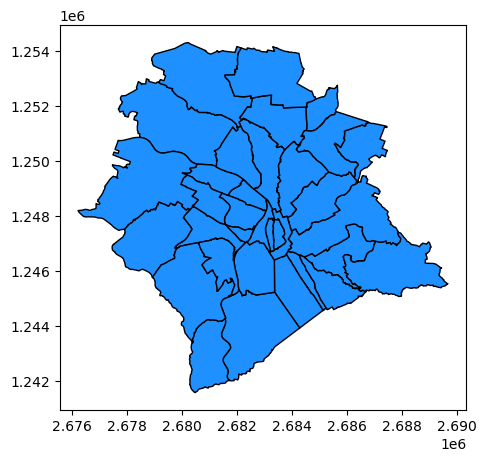

In [4]:
# Instantly visualize the geometric shapes
zh_dist_gdf.plot(figsize=(8, 5), color="dodgerblue", edgecolor="black");